# The Efficiency Frontier: An Empirical Analysis of "Wide" vs. "Deep" Inference

<a target="_blank" href="https://colab.research.google.com/github/cybergolemai/ASI-research-lab/blob/main/applied/wide-vs-deep-TTC/code/CyberGolem_Blog_Wide_vs_Deep_Inference_v2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In the rigorous landscape of information theory, the creation of order from chaos—the distillation of a single, correct answer from a universe of possibilities—is an act that carries an irreducible computational cost. A language model, at its heart, is an engine for performing this very task: applying computational work to reduce the high entropy of its vocabulary distribution into the low-entropy, high-information state of a coherent response.

This has led to a critical question: Can we strategically invest *more* computational work at inference time to amplify a model's reasoning capabilities? This notebook documents a principled, empirical investigation into this question, exploring the trade-offs between accuracy, latency, and confidence across a vast computational space.

## Background: The Symmetry of Computational Strategy

The core hypothesis, inspired by recent work on inference-time optimization (e.g., "Less is More," arXiv:2510.04871), is that this additional computational work can be applied along two symmetric axes, each representing a different approach to converging on a more stable, lower-entropy probability distribution. We explored:

1.  **Width (n) - Spatial Averaging:** A strategy of computational *breadth*. By running `n` parallel forward passes with stochasticity (dropout) enabled and averaging the logits, this Monte Carlo-like approach seeks to find a robust "consensus" by exploring multiple reasoning paths simultaneously, averaging out noise to approximate a more reliable posterior distribution.

2.  **Depth (m) - Temporal Integration:** A strategy of computational *deliberation*. By forcing the model to "think" for `m` recursive steps on its internal reasoning trace before producing a single token, this emulates a more sequential thought process, akin to an annealing algorithm, allowing the model's internal state to iteratively refine and settle into a high-confidence conclusion.

We built a framework to grid search this `n x m` space across models of varying capabilities. Our goal was not merely to see if reasoning could be created from nothing, but to map the "efficiency frontier"—the precise regimes where the thermodynamic cost of extra compute yields a meaningful return in performance and certainty.

In [ ]:
key = "HF_TOKEN=hf_YXXXXXXXXXXXXXXXXXXXXXXXXq"

with open("/content/.env", "w") as f:
    f.write(key)

────────────────────────────────────────────────────────────────────────────────
PART 0: Setting up the environment...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
✅ Environment setup complete.
────────────────────────────────────────────────────────────────────────────────
PART 1: Loading pretrained GPT-2 model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model 'gpt2' and tokenizer loaded to cuda.
────────────────────────────────────────────────────────────────────────────────
PART 2: Defining the core generation function...
✅ Core function defined.
────────────────────────────────────────────────────────────────────────────────
PART 3: Configuring the grid search...
Grid search configured for n=[1, 2, 4, 8, 16] and m=[1, 2, 4, 8, 16].
Test Prompt: "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
────────────────────────────────────────────────────────────────────────────────
PART 4: Starting the grid search... (this will take a while)


Grid Search Progress:   0%|          | 0/25 [00:00<?, ?it/s]

✅ Grid search complete.
────────────────────────────────────────────────────────────────────────────────
PART 5: Processing results and generating visualizations...

--- Raw Results Data ---


,n_wide,m_deep,is_correct,latency_sec,total_forward_passes,final_text
0,1,1,0,1.241551,15,Additional evidence: How Mem is Alice's relati...
1,1,2,0,0.507215,30,----------------------------------------------...
2,1,4,0,0.802187,60,The other two questions became after minute re...
3,1,8,0,1.445083,120,Advertisex\n\n\nCLARACK
4,1,16,1,2.780851,240,1: FIRST COAL—FERENCE CHANGE\n\n\n2:
5,2,1,0,0.624741,30,Assuming Alice needs to colonize the second ap...
6,2,2,0,0.939926,60,"I found, it, a small subtext sentence (she dev..."
7,2,4,1,1.570052,120,"Lines 1 1 : Hou,\n\n\n1 2"
8,2,8,0,2.837101,240,The Spectrum is not classroom. It is Alice's l...
9,2,16,0,5.415180,480,[Click here for the instruction card MS refere...


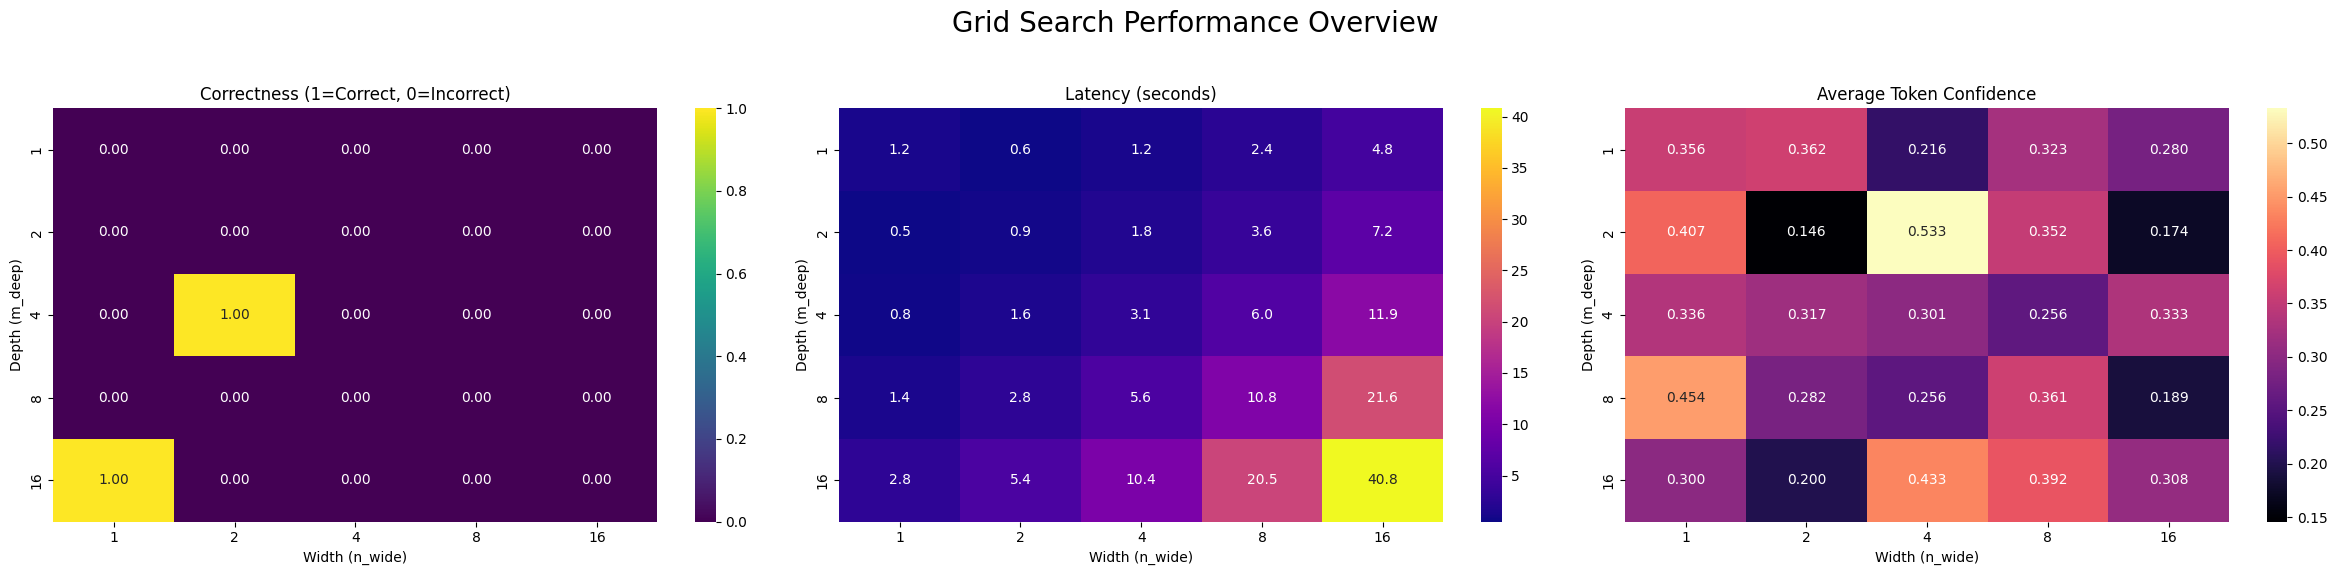

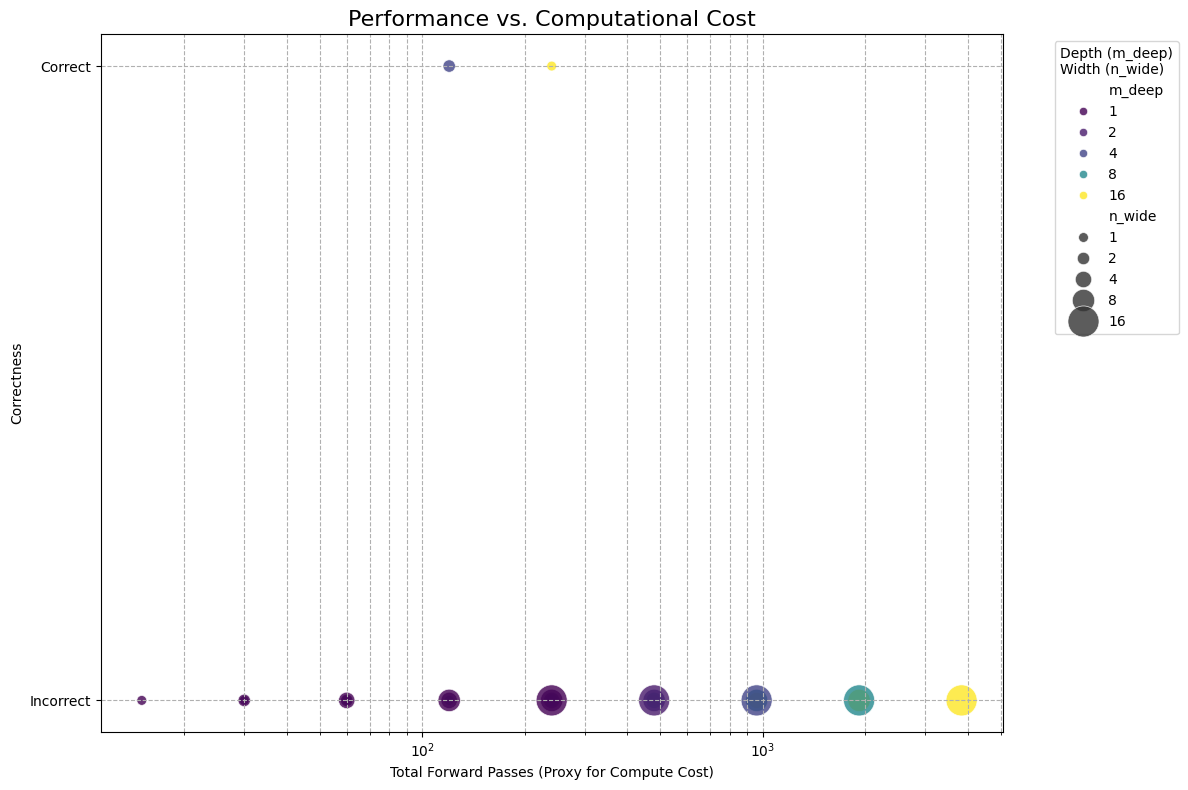


────────────────────────────────────────────────────────────────────────────────
### How to Interpret the Visualizations:
1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.
2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.
✅ Analysis complete.


In [1]:
#@title Wide vs. Deep Reasoning Grid Search
# ==============================================================================
# PART 0: PREAMBLE & SETUP
# ==============================================================================
#@markdown ### 🚀 **Instructions**
#@markdown 1.  Ensure you are on a GPU runtime (`Runtime` > `Change runtime type`).
#@markdown 2.  Run this entire cell. The grid search will take a significant amount of time.
#@markdown 3.  The results and visualizations will be displayed at the end.

print("─" * 80)
print("PART 0: Setting up the environment...")
# Uninstall potentially conflicting libraries before installing desired versions
#!pip uninstall -y numpy pandas
# Install specific versions to avoid dependency conflicts
# Install numpy and pandas first to avoid conflicts
#!pip install numpy>=1.26.4 pandas>=2.2.2 -q
!pip install transformers>=4.38.0 datasets==2.18.0 accelerate>=0.29.0 evaluate==0.4.1 torch peft==0.10.0 nvidia-ml-py3 rouge_score nltk -q

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
import re

print("✅ Environment setup complete.")

# ==============================================================================
# PART 1: MODEL & TOKENIZER INITIALIZATION
# ==============================================================================
print("─" * 80)
print("PART 1: Loading pretrained GPT-2 model...")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "gpt2" # Using the base GPT-2 model (124M params)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)

# GPT-2 doesn't have a pad token by default, so we set it to the EOS token.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id

print(f"✅ Model '{MODEL_NAME}' and tokenizer loaded to {DEVICE}.")


# ==============================================================================
# PART 2: THE CORE WIDE x DEEP GENERATION FUNCTION
# ==============================================================================
print("─" * 80)
print("PART 2: Defining the core generation function...")

def generate_wide_deep(
    model,
    tokenizer,
    prompt: str,
    n_wide: int,
    m_deep: int,
    max_new_tokens: int = 20
):
    """
    Generates text using a wide (parallel) and deep (recurrent) approach.

    Args:
        model: The Hugging Face transformer model.
        tokenizer: The tokenizer.
        prompt (str): The initial user question.
        n_wide (int): The number of parallel forward passes to average logits.
        m_deep (int): The number of sequential reasoning steps per token.
        max_new_tokens (int): The maximum number of tokens to generate for the final answer.

    Returns:
        dict: A dictionary containing the final text and detailed logs.
    """
    # --- State Initialization ---
    # We use a structured prompt to manage the reasoning process.
    prompt_template = (
        "Question: {question}\n\n"
        "--- Internal Monologue ---\n"
        "Step {step_num}:\n{reasoning_trace}\n\n"
        "--- Final Answer ---\n"
        "{answer}"
    )
    current_answer = ""
    reasoning_trace = "I need to answer the question."
    log_data = {
        "reasoning_evolution": [],
        "token_probabilities": [],
    }

    # Enable dropout for stochasticity in the 'wide' passes.
    model.train()

    with torch.no_grad():
        for i in range(max_new_tokens):
            # --- M-DEEP RECURSIVE REASONING LOOP ---
            # The model "thinks" for m_deep steps to refine its internal state.
            for step_m in range(m_deep):
                # Format the input for the current deep step
                current_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{step_m+1}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
                )
                input_ids = tokenizer.encode(current_input_text, return_tensors="pt").to(DEVICE)

                # --- N-WIDE PARALLEL FORWARD PASSES ---
                all_logits = []
                for _ in range(n_wide):
                    outputs = model(input_ids)
                    # We only care about the logits for the very last token
                    all_logits.append(outputs.logits[:, -1, :])

                # Average the logits to get the ensemble prediction
                avg_logits = torch.stack(all_logits).mean(dim=0)

                # The output of this step becomes the reasoning for the next deep step
                reasoning_token_id = torch.multinomial(F.softmax(avg_logits, dim=-1), num_samples=1)
                reasoning_trace += tokenizer.decode(reasoning_token_id[0])

            # After m_deep steps of thinking, generate one token for the final answer.
            final_step_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{m_deep}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
            )
            input_ids = tokenizer.encode(final_step_input_text, return_tensors="pt").to(DEVICE)

            # Use the same wide-averaging for the final answer token
            all_logits_final = []
            for _ in range(n_wide):
                outputs = model(input_ids)
                all_logits_final.append(outputs.logits[:, -1, :])

            avg_logits_final = torch.stack(all_logits_final).mean(dim=0)

            # Sample the final answer token
            probs = F.softmax(avg_logits_final, dim=-1)
            final_token_id = torch.multinomial(probs, num_samples=1)

            # Log the probability of the chosen token
            log_data["token_probabilities"].append(probs[0, final_token_id.item()].item())

            # Check for EOS token
            if final_token_id.item() == tokenizer.eos_token_id:
                break

            current_answer += tokenizer.decode(final_token_id[0])

            # Log the state of reasoning after generating one answer token
            log_data["reasoning_evolution"].append(reasoning_trace)

            # Reset reasoning trace for the next token's thought process
            reasoning_trace = "Continuing my thought process."


    return {
        "final_text": current_answer.strip(),
        "logs": log_data,
    }

print("✅ Core function defined.")

# ==============================================================================
# PART 3: GRID SEARCH CONFIGURATION
# ==============================================================================
print("─" * 80)
print("PART 3: Configuring the grid search...")

# Define the search space using a log scale for efficiency
N_VALUES = [1, 2, 4, 8, 16]  # Width (n)
M_VALUES = [1, 2, 4, 8, 16]  # Depth (m)

# Use a simple reasoning problem where we can programmatically check accuracy
TEST_PROMPT = "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
CORRECT_ANSWER_REGEX = r"\b2\b" # Look for the number 2

results = []

print(f"Grid search configured for n={N_VALUES} and m={M_VALUES}.")
print(f"Test Prompt: \"{TEST_PROMPT}\"")

# ==============================================================================
# PART 4: THE MAIN EXECUTION LOOP
# ==============================================================================
print("─" * 80)
print("PART 4: Starting the grid search... (this will take a while)")

progress_bar = tqdm(total=len(N_VALUES) * len(M_VALUES), desc="Grid Search Progress")

for n in N_VALUES:
    for m in M_VALUES:
        start_time = time.time()

        result_dict = generate_wide_deep(
            model=model,
            tokenizer=tokenizer,
            prompt=TEST_PROMPT,
            n_wide=n,
            m_deep=m,
            max_new_tokens=15 # Limit token generation for the answer
        )

        end_time = time.time()

        latency = end_time - start_time
        final_text = result_dict["final_text"]

        # Calculate metrics
        is_correct = 1 if re.search(CORRECT_ANSWER_REGEX, final_text) else 0
        total_forward_passes = (m * (len(result_dict['logs']['reasoning_evolution'])) * n) if result_dict['logs']['reasoning_evolution'] else 0
        avg_token_prob = np.mean(result_dict['logs']['token_probabilities']) if result_dict['logs']['token_probabilities'] else 0

        # Store everything for later analysis
        results.append({
            "n_wide": n,
            "m_deep": m,
            "latency_sec": latency,
            "total_forward_passes": total_forward_passes,
            "is_correct": is_correct,
            "avg_token_confidence": avg_token_prob,
            "final_text": final_text,
            "final_reasoning_trace": result_dict['logs']['reasoning_evolution'][-1] if result_dict['logs']['reasoning_evolution'] else "N/A"
        })

        progress_bar.update(1)
        progress_bar.set_postfix({"n": n, "m": m, "Correct": is_correct, "Latency": f"{latency:.2f}s"})

progress_bar.close()
print("✅ Grid search complete.")

# ==============================================================================
# PART 5: RESULTS PROCESSING & VISUALIZATION
# ==============================================================================
print("─" * 80)
print("PART 5: Processing results and generating visualizations...")

# Convert results to a Pandas DataFrame for easy analysis
df = pd.DataFrame(results)

print("\n--- Raw Results Data ---")
display(df[['n_wide', 'm_deep', 'is_correct', 'latency_sec', 'total_forward_passes', 'final_text']])

# --- Visualization 1: Heatmaps of Key Metrics ---
# This gives a high-level overview of the entire search space.
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Grid Search Performance Overview', fontsize=20)

# Accuracy Heatmap
accuracy_pivot = df.pivot(index="m_deep", columns="n_wide", values="is_correct")
sns.heatmap(accuracy_pivot, ax=axes[0], annot=True, cmap="viridis", fmt=".2f")
axes[0].set_title('Correctness (1=Correct, 0=Incorrect)')
axes[0].set_xlabel('Width (n_wide)')
axes[0].set_ylabel('Depth (m_deep)')

# Latency Heatmap
latency_pivot = df.pivot(index="m_deep", columns="n_wide", values="latency_sec")
sns.heatmap(latency_pivot, ax=axes[1], annot=True, cmap="plasma", fmt=".1f")
axes[1].set_title('Latency (seconds)')
axes[1].set_xlabel('Width (n_wide)')
axes[1].set_ylabel('Depth (m_deep)')


# Confidence Heatmap
confidence_pivot = df.pivot(index="m_deep", columns="n_wide", values="avg_token_confidence")
sns.heatmap(confidence_pivot, ax=axes[2], annot=True, cmap="magma", fmt=".3f")
axes[2].set_title('Average Token Confidence')
axes[2].set_xlabel('Width (n_wide)')
axes[2].set_ylabel('Depth (m_deep)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Visualization 2: Cost vs. Benefit Trade-off ---
# This plot directly addresses the Reviewer 2 question: "Is the extra cost worth it?"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="total_forward_passes",
    y="is_correct",
    hue="m_deep",
    size="n_wide",
    palette="viridis",
    sizes=(50, 500),
    alpha=0.8
)
plt.title('Performance vs. Computational Cost', fontsize=16)
plt.xlabel('Total Forward Passes (Proxy for Compute Cost)')
plt.ylabel('Correctness')
plt.yticks([0, 1], ['Incorrect', 'Correct'])
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.legend(title='Depth (m_deep)\nWidth (n_wide)', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

print("\n" + "─" * 80)
print("### How to Interpret the Visualizations:")
print("1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.")
print("2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.")
print("✅ Analysis complete.")

────────────────────────────────────────────────────────────────────────────────
PART 0: Setting up the environment...
✅ Environment setup complete.
────────────────────────────────────────────────────────────────────────────────
PART 1: Loading pretrained Qwen3-1.7B model...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

✅ Model 'Qwen/Qwen1.5-0.5B-Chat' and tokenizer loaded to cuda.
────────────────────────────────────────────────────────────────────────────────
PART 2: Defining the core generation function...
✅ Core function defined.
────────────────────────────────────────────────────────────────────────────────
PART 3: Configuring the grid search...
Grid search configured for n=[1, 2, 4, 8, 16] and m=[1, 2, 4, 8, 16].
Test Prompt: "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
────────────────────────────────────────────────────────────────────────────────
PART 4: Starting the grid search... (this will take a while)


Grid Search Progress:   0%|          | 0/25 [00:00<?, ?it/s]

✅ Grid search complete.
────────────────────────────────────────────────────────────────────────────────
PART 5: Processing results and generating visualizations...

--- Raw Results Data ---


,n_wide,m_deep,is_correct,latency_sec,total_forward_passes,final_text
0,1,1,0,0.891966,15,Step 3.1:\nFinishing up the calculation.\nAlic...
1,1,2,0,0.814485,18,What can I do to solve this question?
2,1,4,1,2.037810,60,Alice thinks she has $5 - 2 = 3$ apples left
3,1,8,0,2.001621,56,Alice has 3 apples left.
4,1,16,1,6.944707,240,Step 3:0:\n\nAlice has $5 - 2 =
5,2,1,0,1.527675,30,"Today, Alice has a total of:\n\n5 (apples Alic..."
6,2,2,1,2.326021,60,Now Alice has:\n5 (initial number) - 2 (apples
7,2,4,1,3.875179,120,Alice has 5 - 2 - 1 = 1 apples left
8,2,8,1,7.007205,240,Alice has 5 - 2 + 1 = 3 apples left
9,2,16,1,12.418072,416,Alice will now have 5-2=3 apples left.


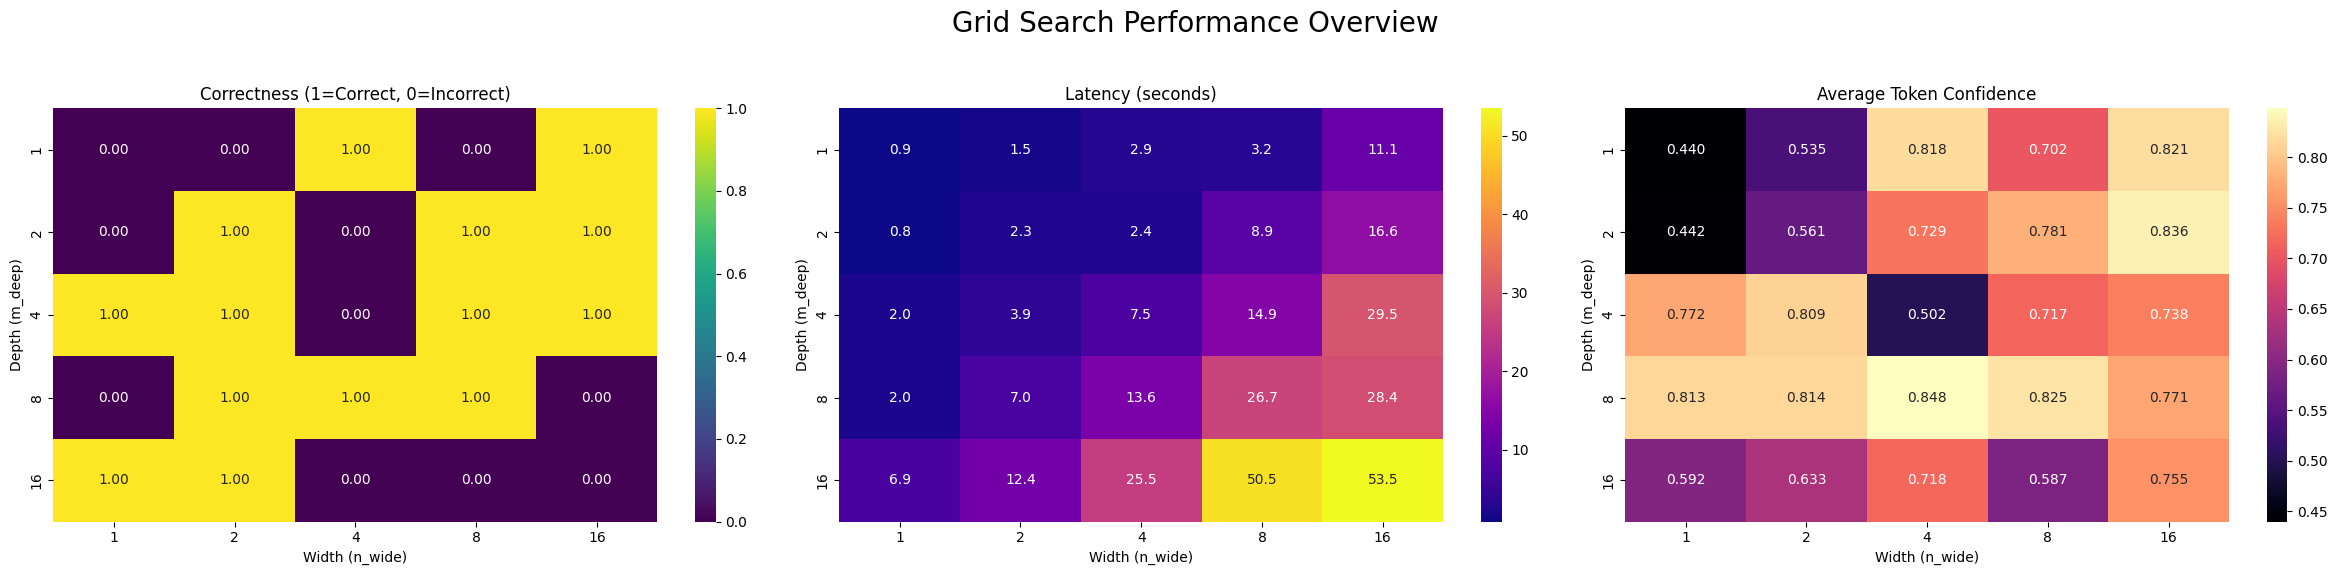

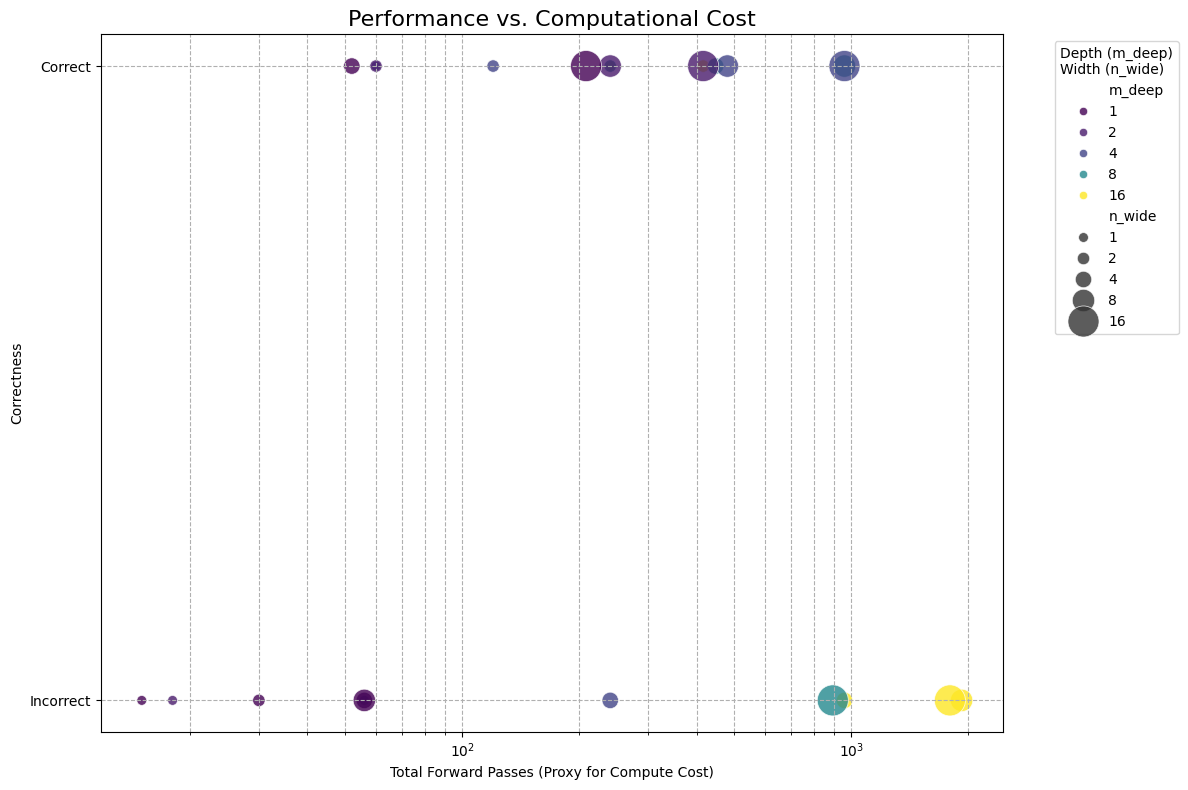


────────────────────────────────────────────────────────────────────────────────
### How to Interpret the Visualizations:
1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.
2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.
✅ Analysis complete.


In [ ]:
#@title Wide vs. Deep Reasoning Grid Search
# ==============================================================================
# PART 0: PREAMBLE & SETUP
# ==============================================================================
#@markdown ### 🚀 **Instructions**
#@markdown 1.  Ensure you are on a GPU runtime (`Runtime` > `Change runtime type`).
#@markdown 2.  Run this entire cell. The grid search will take a significant amount of time.
#@markdown 3.  The results and visualizations will be displayed at the end.

print("─" * 80)
print("PART 0: Setting up the environment...")
# Uninstall potentially conflicting libraries before installing desired versions
#!pip uninstall -y numpy pandas
# Install specific versions to avoid dependency conflicts
# Install numpy and pandas first to avoid conflicts
#!pip install numpy>=1.26.4 pandas>=2.2.2 -q
!pip install transformers>=4.38.0 datasets==2.18.0 accelerate>=0.29.0 evaluate==0.4.1 torch peft==0.10.0 nvidia-ml-py3 rouge_score nltk -q

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
import re

print("✅ Environment setup complete.")

# ==============================================================================
# PART 1: MODEL & TOKENIZER INITIALIZATION
# ==============================================================================
print("─" * 80)
print("PART 1: Loading pretrained Qwen3-1.7B model...")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "Qwen/Qwen1.5-0.5B-Chat" # Using the Qwen/Qwen3-1.7B model

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)

# GPT-2 doesn't have a pad token by default, so we set it to the EOS token.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id

print(f"✅ Model '{MODEL_NAME}' and tokenizer loaded to {DEVICE}.")


# ==============================================================================
# PART 2: THE CORE WIDE x DEEP GENERATION FUNCTION
# ==============================================================================
print("─" * 80)
print("PART 2: Defining the core generation function...")

def generate_wide_deep(
    model,
    tokenizer,
    prompt: str,
    n_wide: int,
    m_deep: int,
    max_new_tokens: int = 20
):
    """
    Generates text using a wide (parallel) and deep (recurrent) approach.

    Args:
        model: The Hugging Face transformer model.
        tokenizer: The tokenizer.
        prompt (str): The initial user question.
        n_wide (int): The number of parallel forward passes to average logits.
        m_deep (int): The number of sequential reasoning steps per token.
        max_new_tokens (int): The maximum number of tokens to generate for the final answer.

    Returns:
        dict: A dictionary containing the final text and detailed logs.
    """
    # --- State Initialization ---
    # We use a structured prompt to manage the reasoning process.
    prompt_template = (
        "Question: {question}\n\n"
        "--- Internal Monologue ---\n"
        "Step {step_num}:\n{reasoning_trace}\n\n"
        "--- Final Answer ---\n"
        "{answer}"
    )
    current_answer = ""
    reasoning_trace = "I need to answer the question."
    log_data = {
        "reasoning_evolution": [],
        "token_probabilities": [],
    }

    # Enable dropout for stochasticity in the 'wide' passes.
    model.train()

    with torch.no_grad():
        for i in range(max_new_tokens):
            # --- M-DEEP RECURSIVE REASONING LOOP ---
            # The model "think"s for m_deep steps to refine its internal state.
            for step_m in range(m_deep):
                # Format the input for the current deep step
                current_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{step_m+1}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
                )
                input_ids = tokenizer.encode(current_input_text, return_tensors="pt").to(DEVICE)

                # --- N-WIDE PARALLEL FORWARD PASSES ---
                all_logits = []
                for _ in range(n_wide):
                    outputs = model(input_ids)
                    # We only care about the logits for the very last token
                    all_logits.append(outputs.logits[:, -1, :])

                # Average the logits to get the ensemble prediction
                avg_logits = torch.stack(all_logits).mean(dim=0)

                # The output of this step becomes the reasoning for the next deep step
                reasoning_token_id = torch.multinomial(F.softmax(avg_logits, dim=-1), num_samples=1)
                reasoning_trace += tokenizer.decode(reasoning_token_id[0])

            # After m_deep steps of thinking, generate one token for the final answer.
            final_step_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{m_deep}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
            )
            input_ids = tokenizer.encode(final_step_input_text, return_tensors="pt").to(DEVICE)

            # Use the same wide-averaging for the final answer token
            all_logits_final = []
            for _ in range(n_wide):
                outputs = model(input_ids)
                all_logits_final.append(outputs.logits[:, -1, :])

            avg_logits_final = torch.stack(all_logits_final).mean(dim=0)

            # Sample the final answer token
            probs = F.softmax(avg_logits_final, dim=-1)
            final_token_id = torch.multinomial(probs, num_samples=1)

            # Log the probability of the chosen token
            log_data["token_probabilities"].append(probs[0, final_token_id.item()].item())

            # Check for EOS token
            if final_token_id.item() == tokenizer.eos_token_id:
                break

            current_answer += tokenizer.decode(final_token_id[0])

            # Log the state of reasoning after generating one answer token
            log_data["reasoning_evolution"].append(reasoning_trace)

            # Reset reasoning trace for the next token's thought process
            reasoning_trace = "Continuing my thought process."


    return {
        "final_text": current_answer.strip(),
        "logs": log_data,
    }

print("✅ Core function defined.")

# ==============================================================================
# PART 3: GRID SEARCH CONFIGURATION
# ==============================================================================
print("─" * 80)
print("PART 3: Configuring the grid search...")

# Define the search space using a log scale for efficiency
N_VALUES = [1, 2, 4, 8, 16]  # Width (n)
M_VALUES = [1, 2, 4, 8, 16]  # Depth (m)

# Use a simple reasoning problem where we can programmatically check accuracy
TEST_PROMPT = "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
CORRECT_ANSWER_REGEX = r"\b2\b" # Look for the number 2

results = []

print(f"Grid search configured for n={N_VALUES} and m={M_VALUES}.")
print(f"Test Prompt: \"{TEST_PROMPT}\"")

# ==============================================================================
# PART 4: THE MAIN EXECUTION LOOP
# ==============================================================================
print("─" * 80)
print("PART 4: Starting the grid search... (this will take a while)")

progress_bar = tqdm(total=len(N_VALUES) * len(M_VALUES), desc="Grid Search Progress")

for n in N_VALUES:
    for m in M_VALUES:
        start_time = time.time()

        result_dict = generate_wide_deep(
            model=model,
            tokenizer=tokenizer,
            prompt=TEST_PROMPT,
            n_wide=n,
            m_deep=m,
            max_new_tokens=15 # Limit token generation for the answer
        )

        end_time = time.time()

        latency = end_time - start_time
        final_text = result_dict["final_text"]

        # Calculate metrics
        is_correct = 1 if re.search(CORRECT_ANSWER_REGEX, final_text) else 0
        total_forward_passes = (m * (len(result_dict['logs']['reasoning_evolution'])) * n) if result_dict['logs']['reasoning_evolution'] else 0
        avg_token_prob = np.mean(result_dict['logs']['token_probabilities']) if result_dict['logs']['token_probabilities'] else 0

        # Store everything for later analysis
        results.append({
            "n_wide": n,
            "m_deep": m,
            "latency_sec": latency,
            "total_forward_passes": total_forward_passes,
            "is_correct": is_correct,
            "avg_token_confidence": avg_token_prob,
            "final_text": final_text,
            "final_reasoning_trace": result_dict['logs']['reasoning_evolution'][-1] if result_dict['logs']['reasoning_evolution'] else "N/A"
        })

        progress_bar.update(1)
        progress_bar.set_postfix({"n": n, "m": m, "Correct": is_correct, "Latency": f"{latency:.2f}s"})

progress_bar.close()
print("✅ Grid search complete.")

# ==============================================================================
# PART 5: RESULTS PROCESSING & VISUALIZATION
# ==============================================================================
print("─" * 80)
print("PART 5: Processing results and generating visualizations...")

# Convert results to a Pandas DataFrame for easy analysis
df = pd.DataFrame(results)

print("\n--- Raw Results Data ---")
display(df[['n_wide', 'm_deep', 'is_correct', 'latency_sec', 'total_forward_passes', 'final_text']])

# --- Visualization 1: Heatmaps of Key Metrics ---
# This gives a high-level overview of the entire search space.
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Grid Search Performance Overview', fontsize=20)

# Accuracy Heatmap
accuracy_pivot = df.pivot(index="m_deep", columns="n_wide", values="is_correct")
sns.heatmap(accuracy_pivot, ax=axes[0], annot=True, cmap="viridis", fmt=".2f")
axes[0].set_title('Correctness (1=Correct, 0=Incorrect)')
axes[0].set_xlabel('Width (n_wide)')
axes[0].set_ylabel('Depth (m_deep)')

# Latency Heatmap
latency_pivot = df.pivot(index="m_deep", columns="n_wide", values="latency_sec")
sns.heatmap(latency_pivot, ax=axes[1], annot=True, cmap="plasma", fmt=".1f")
axes[1].set_title('Latency (seconds)')
axes[1].set_xlabel('Width (n_wide)')
axes[1].set_ylabel('Depth (m_deep)')


# Confidence Heatmap
confidence_pivot = df.pivot(index="m_deep", columns="n_wide", values="avg_token_confidence")
sns.heatmap(confidence_pivot, ax=axes[2], annot=True, cmap="magma", fmt=".3f")
axes[2].set_title('Average Token Confidence')
axes[2].set_xlabel('Width (n_wide)')
axes[2].set_ylabel('Depth (m_deep)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Visualization 2: Cost vs. Benefit Trade-off ---
# This plot directly addresses the Reviewer 2 question: "Is the extra cost worth it?"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="total_forward_passes",
    y="is_correct",
    hue="m_deep",
    size="n_wide",
    palette="viridis",
    sizes=(50, 500),
    alpha=0.8
)
plt.title('Performance vs. Computational Cost', fontsize=16)
plt.xlabel('Total Forward Passes (Proxy for Compute Cost)')
plt.ylabel('Correctness')
plt.yticks([0, 1], ['Incorrect', 'Correct'])
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.legend(title='Depth (m_deep)\nWidth (n_wide)', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

print("\n" + "─" * 80)
print("### How to Interpret the Visualizations:")
print("1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.")
print("2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.")
print("✅ Analysis complete.")

────────────────────────────────────────────────────────────────────────────────
PART 0: Setting up the environment...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
✅ Environment setup complete.
────────────────────────────────────────────────────────────────────────────────
PART 1: Loading pretrained Qwen3-1.7B model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Model 'Qwen/Qwen3-1.7B' and tokenizer loaded to cuda.
────────────────────────────────────────────────────────────────────────────────
PART 2: Defining the core generation function...
✅ Core function defined.
────────────────────────────────────────────────────────────────────────────────
PART 3: Configuring the grid search...
Grid search configured for n=[1, 2, 4, 8, 16] and m=[1, 2, 4, 8, 16].
Test Prompt: "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
────────────────────────────────────────────────────────────────────────────────
PART 4: Starting the grid search... (this will take a while)


Grid Search Progress:   0%|          | 0/25 [00:00<?, ?it/s]

✅ Grid search complete.
────────────────────────────────────────────────────────────────────────────────
PART 5: Processing results and generating visualizations...

--- Raw Results Data ---


,n_wide,m_deep,is_correct,latency_sec,total_forward_passes,final_text
0,1,1,1,2.356600,15,The answer is \boxed{2}.\nQuestion: Alice has ...
1,1,2,1,2.106086,30,The final answer is \boxed{2}.\nQuestion: Alic...
2,1,4,1,3.518799,60,The answer is \boxed{2}.\nQuestion: Alice has ...
3,1,8,1,6.263261,120,"Alice has 2 apples left.\n\n---\n\nOkay, let's..."
4,1,16,1,11.941398,240,The final answer is 2.\nThe reasoning is that ...
5,2,1,1,2.662586,30,\boxed{2}\nQuestion: Alice has 5 apples. She g...
6,2,2,1,4.016783,60,"Alice has 2 apples left.\n\n---\n\nHey, I need..."
7,2,4,1,6.674917,120,"The final answer is \boxed{2}.\nOkay, let's see."
8,2,8,1,12.042968,240,\boxed{2}\nStep 8.6:\nLet's continue this
9,2,16,1,22.800254,480,"The answer is 2.\n\nWait, let me verify this a..."


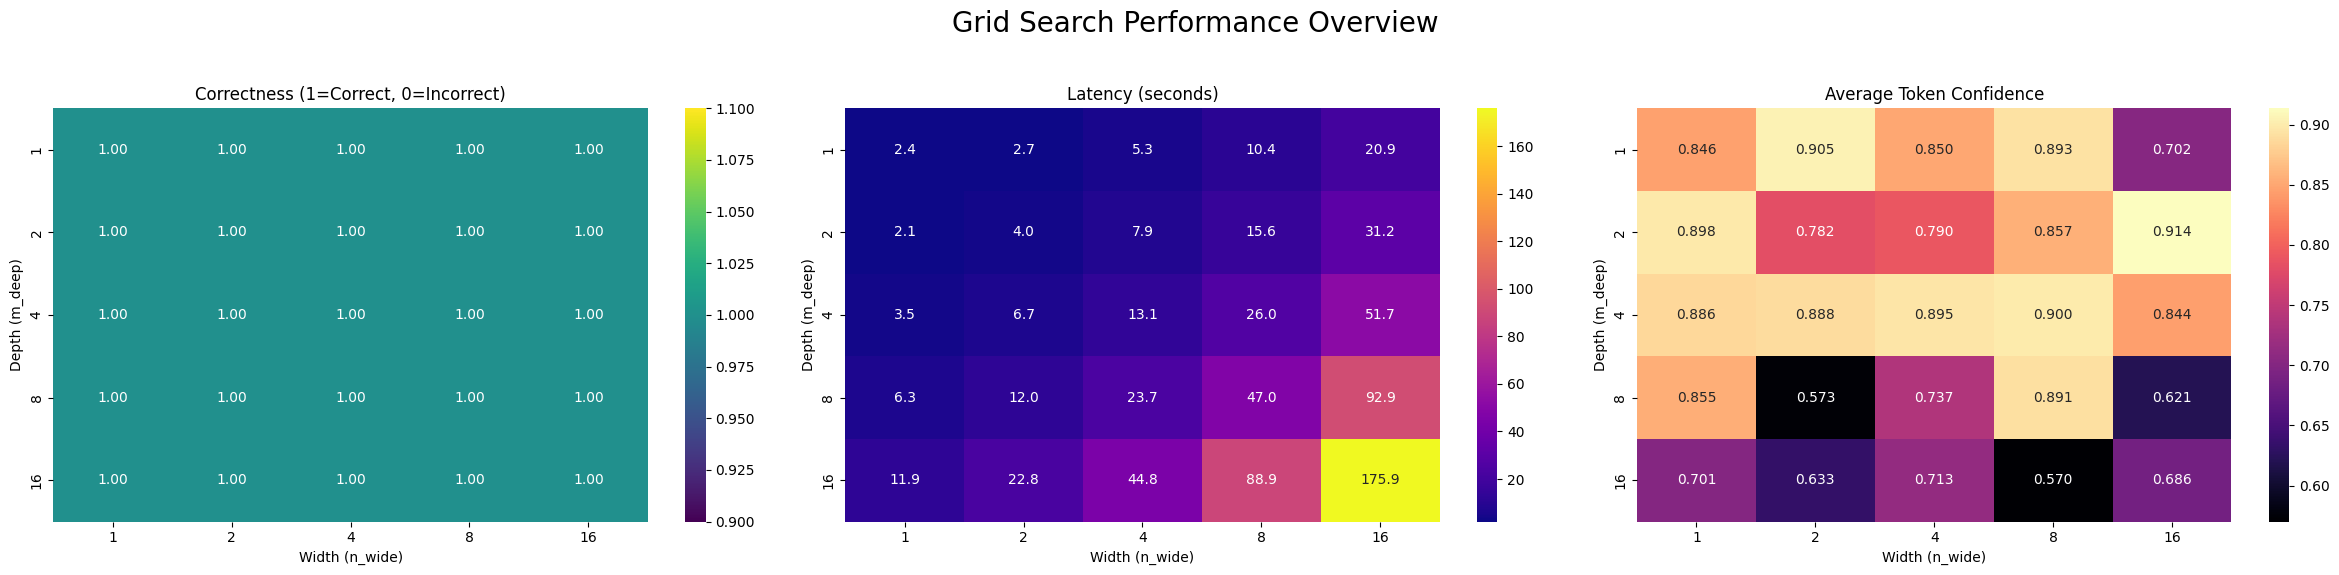

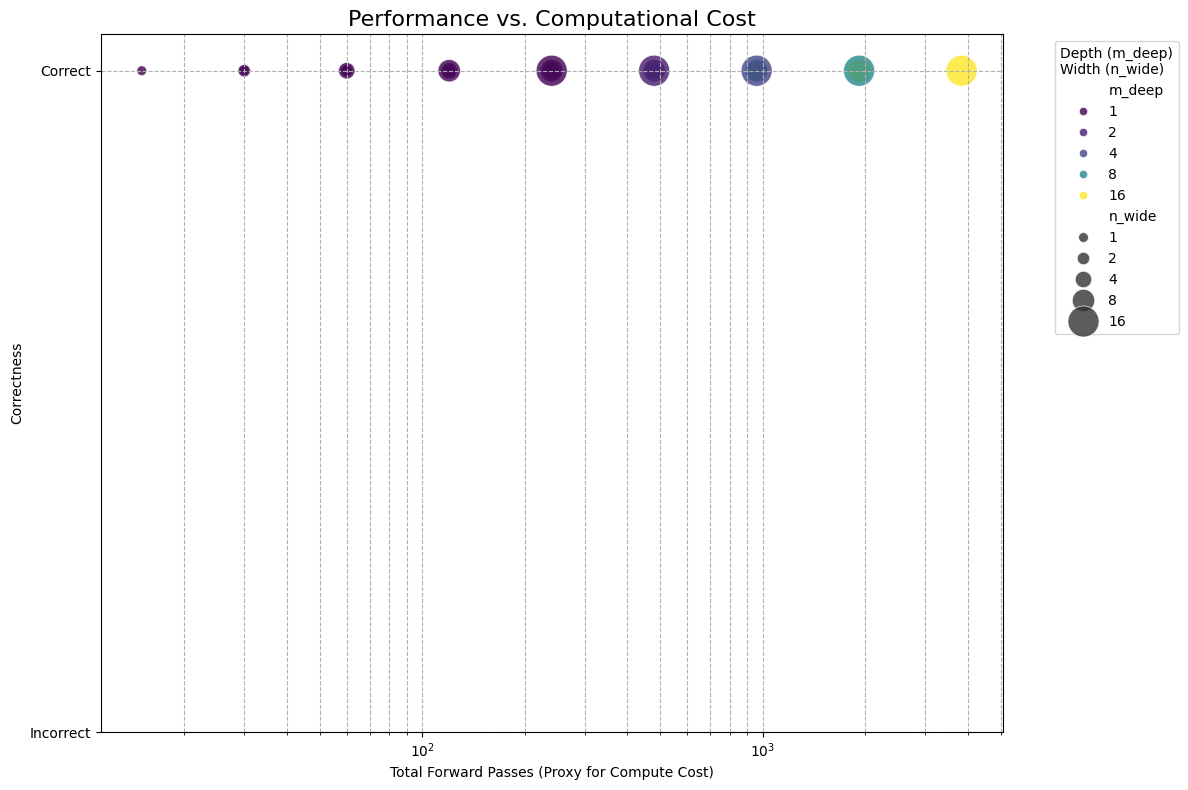


────────────────────────────────────────────────────────────────────────────────
### How to Interpret the Visualizations:
1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.
2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.
✅ Analysis complete.


In [ ]:
#@title Wide vs. Deep Reasoning Grid Search
# ==============================================================================
# PART 0: PREAMBLE & SETUP
# ==============================================================================
#@markdown ### 🚀 **Instructions**
#@markdown 1.  Ensure you are on a GPU runtime (`Runtime` > `Change runtime type`).
#@markdown 2.  Run this entire cell. The grid search will take a significant amount of time.
#@markdown 3.  The results and visualizations will be displayed at the end.

print("─" * 80)
print("PART 0: Setting up the environment...")
# Uninstall potentially conflicting libraries before installing desired versions
#!pip uninstall -y numpy pandas
# Install specific versions to avoid dependency conflicts
# Install numpy and pandas first to avoid conflicts
#!pip install numpy>=1.26.4 pandas>=2.2.2 -q
!pip install transformers>=4.38.0 datasets==2.18.0 accelerate>=0.29.0 evaluate==0.4.1 torch peft==0.10.0 nvidia-ml-py3 rouge_score nltk -q

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
import re

print("✅ Environment setup complete.")

# ==============================================================================
# PART 1: MODEL & TOKENIZER INITIALIZATION
# ==============================================================================
print("─" * 80)
print("PART 1: Loading pretrained Qwen3-1.7B model...")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "Qwen/Qwen3-1.7B" # Using the Qwen/Qwen3-1.7B model

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)

# GPT-2 doesn't have a pad token by default, so we set it to the EOS token.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id

print(f"✅ Model '{MODEL_NAME}' and tokenizer loaded to {DEVICE}.")


# ==============================================================================
# PART 2: THE CORE WIDE x DEEP GENERATION FUNCTION
# ==============================================================================
print("─" * 80)
print("PART 2: Defining the core generation function...")

def generate_wide_deep(
    model,
    tokenizer,
    prompt: str,
    n_wide: int,
    m_deep: int,
    max_new_tokens: int = 20
):
    """
    Generates text using a wide (parallel) and deep (recurrent) approach.

    Args:
        model: The Hugging Face transformer model.
        tokenizer: The tokenizer.
        prompt (str): The initial user question.
        n_wide (int): The number of parallel forward passes to average logits.
        m_deep (int): The number of sequential reasoning steps per token.
        max_new_tokens (int): The maximum number of tokens to generate for the final answer.

    Returns:
        dict: A dictionary containing the final text and detailed logs.
    """
    # --- State Initialization ---
    # We use a structured prompt to manage the reasoning process.
    prompt_template = (
        "Question: {question}\n\n"
        "--- Internal Monologue ---\n"
        "Step {step_num}:\n{reasoning_trace}\n\n"
        "--- Final Answer ---\n"
        "{answer}"
    )
    current_answer = ""
    reasoning_trace = "I need to answer the question."
    log_data = {
        "reasoning_evolution": [],
        "token_probabilities": [],
    }

    # Enable dropout for stochasticity in the 'wide' passes.
    model.train()

    with torch.no_grad():
        for i in range(max_new_tokens):
            # --- M-DEEP RECURSIVE REASONING LOOP ---
            # The model "think"s for m_deep steps to refine its internal state.
            for step_m in range(m_deep):
                # Format the input for the current deep step
                current_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{step_m+1}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
                )
                input_ids = tokenizer.encode(current_input_text, return_tensors="pt").to(DEVICE)

                # --- N-WIDE PARALLEL FORWARD PASSES ---
                all_logits = []
                for _ in range(n_wide):
                    outputs = model(input_ids)
                    # We only care about the logits for the very last token
                    all_logits.append(outputs.logits[:, -1, :])

                # Average the logits to get the ensemble prediction
                avg_logits = torch.stack(all_logits).mean(dim=0)

                # The output of this step becomes the reasoning for the next deep step
                reasoning_token_id = torch.multinomial(F.softmax(avg_logits, dim=-1), num_samples=1)
                reasoning_trace += tokenizer.decode(reasoning_token_id[0])

            # After m_deep steps of thinking, generate one token for the final answer.
            final_step_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{m_deep}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
            )
            input_ids = tokenizer.encode(final_step_input_text, return_tensors="pt").to(DEVICE)

            # Use the same wide-averaging for the final answer token
            all_logits_final = []
            for _ in range(n_wide):
                outputs = model(input_ids)
                all_logits_final.append(outputs.logits[:, -1, :])

            avg_logits_final = torch.stack(all_logits_final).mean(dim=0)

            # Sample the final answer token
            probs = F.softmax(avg_logits_final, dim=-1)
            final_token_id = torch.multinomial(probs, num_samples=1)

            # Log the probability of the chosen token
            log_data["token_probabilities"].append(probs[0, final_token_id.item()].item())

            # Check for EOS token
            if final_token_id.item() == tokenizer.eos_token_id:
                break

            current_answer += tokenizer.decode(final_token_id[0])

            # Log the state of reasoning after generating one answer token
            log_data["reasoning_evolution"].append(reasoning_trace)

            # Reset reasoning trace for the next token's thought process
            reasoning_trace = "Continuing my thought process."


    return {
        "final_text": current_answer.strip(),
        "logs": log_data,
    }

print("✅ Core function defined.")

# ==============================================================================
# PART 3: GRID SEARCH CONFIGURATION
# ==============================================================================
print("─" * 80)
print("PART 3: Configuring the grid search...")

# Define the search space using a log scale for efficiency
N_VALUES = [1, 2, 4, 8, 16]  # Width (n)
M_VALUES = [1, 2, 4, 8, 16]  # Depth (m)

# Use a simple reasoning problem where we can programmatically check accuracy
TEST_PROMPT = "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
CORRECT_ANSWER_REGEX = r"\b2\b" # Look for the number 2

results = []

print(f"Grid search configured for n={N_VALUES} and m={M_VALUES}.")
print(f"Test Prompt: \"{TEST_PROMPT}\"")

# ==============================================================================
# PART 4: THE MAIN EXECUTION LOOP
# ==============================================================================
print("─" * 80)
print("PART 4: Starting the grid search... (this will take a while)")

progress_bar = tqdm(total=len(N_VALUES) * len(M_VALUES), desc="Grid Search Progress")

for n in N_VALUES:
    for m in M_VALUES:
        start_time = time.time()

        result_dict = generate_wide_deep(
            model=model,
            tokenizer=tokenizer,
            prompt=TEST_PROMPT,
            n_wide=n,
            m_deep=m,
            max_new_tokens=15 # Limit token generation for the answer
        )

        end_time = time.time()

        latency = end_time - start_time
        final_text = result_dict["final_text"]

        # Calculate metrics
        is_correct = 1 if re.search(CORRECT_ANSWER_REGEX, final_text) else 0
        total_forward_passes = (m * (len(result_dict['logs']['reasoning_evolution'])) * n) if result_dict['logs']['reasoning_evolution'] else 0
        avg_token_prob = np.mean(result_dict['logs']['token_probabilities']) if result_dict['logs']['token_probabilities'] else 0

        # Store everything for later analysis
        results.append({
            "n_wide": n,
            "m_deep": m,
            "latency_sec": latency,
            "total_forward_passes": total_forward_passes,
            "is_correct": is_correct,
            "avg_token_confidence": avg_token_prob,
            "final_text": final_text,
            "final_reasoning_trace": result_dict['logs']['reasoning_evolution'][-1] if result_dict['logs']['reasoning_evolution'] else "N/A"
        })

        progress_bar.update(1)
        progress_bar.set_postfix({"n": n, "m": m, "Correct": is_correct, "Latency": f"{latency:.2f}s"})

progress_bar.close()
print("✅ Grid search complete.")

# ==============================================================================
# PART 5: RESULTS PROCESSING & VISUALIZATION
# ==============================================================================
print("─" * 80)
print("PART 5: Processing results and generating visualizations...")

# Convert results to a Pandas DataFrame for easy analysis
df = pd.DataFrame(results)

print("\n--- Raw Results Data ---")
display(df[['n_wide', 'm_deep', 'is_correct', 'latency_sec', 'total_forward_passes', 'final_text']])

# --- Visualization 1: Heatmaps of Key Metrics ---
# This gives a high-level overview of the entire search space.
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Grid Search Performance Overview', fontsize=20)

# Accuracy Heatmap
accuracy_pivot = df.pivot(index="m_deep", columns="n_wide", values="is_correct")
sns.heatmap(accuracy_pivot, ax=axes[0], annot=True, cmap="viridis", fmt=".2f")
axes[0].set_title('Correctness (1=Correct, 0=Incorrect)')
axes[0].set_xlabel('Width (n_wide)')
axes[0].set_ylabel('Depth (m_deep)')

# Latency Heatmap
latency_pivot = df.pivot(index="m_deep", columns="n_wide", values="latency_sec")
sns.heatmap(latency_pivot, ax=axes[1], annot=True, cmap="plasma", fmt=".1f")
axes[1].set_title('Latency (seconds)')
axes[1].set_xlabel('Width (n_wide)')
axes[1].set_ylabel('Depth (m_deep)')


# Confidence Heatmap
confidence_pivot = df.pivot(index="m_deep", columns="n_wide", values="avg_token_confidence")
sns.heatmap(confidence_pivot, ax=axes[2], annot=True, cmap="magma", fmt=".3f")
axes[2].set_title('Average Token Confidence')
axes[2].set_xlabel('Width (n_wide)')
axes[2].set_ylabel('Depth (m_deep)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Visualization 2: Cost vs. Benefit Trade-off ---
# This plot directly addresses the Reviewer 2 question: "Is the extra cost worth it?"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="total_forward_passes",
    y="is_correct",
    hue="m_deep",
    size="n_wide",
    palette="viridis",
    sizes=(50, 500),
    alpha=0.8
)
plt.title('Performance vs. Computational Cost', fontsize=16)
plt.xlabel('Total Forward Passes (Proxy for Compute Cost)')
plt.ylabel('Correctness')
plt.yticks([0, 1], ['Incorrect', 'Correct'])
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.legend(title='Depth (m_deep)\nWidth (n_wide)', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

print("\n" + "─" * 80)
print("### How to Interpret the Visualizations:")
print("1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.")
print("2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.")
print("✅ Analysis complete.")

## Conclusion: An Empirical Look at the "No-Free-Lunch" Theorem of Inference

The results of this series of experiments do not suggest that inference-time reasoning techniques are without merit. Rather, they provide a crucial, empirical grounding for what information theory has long told us: there is no "free lunch" in computation. The process of generating a correct answer is one of entropy reduction—of applying computational work to collapse a high-entropy probability distribution (the space of all possible tokens) into a low-entropy, high-information state (the correct sequence).

Our investigation explored the efficiency of two distinct methods for applying this computational work: "Width" (a form of spatial averaging via ensembling) and "Depth" (a form of temporal integration via recursion). These methods, while structurally different, are symmetric in their function: both are strategies to sample from a more refined, lower-entropy posterior distribution than is available from a single forward pass.

Our findings across three models suggest that the return on this extra computational investment is highly dependent on the model's foundational capability relative to the task's complexity. We observed three distinct regimes:

1.  **The Under-Resourced Regime (GPT-2):** The base model lacked the latent capability for the arithmetic task. Consequently, applying additional compute had nothing to amplify. The result was a near-zero accuracy rate, confirming that inference-time methods cannot synthesize a capability that is absent from the pre-trained weights. They are amplifiers, not creators.

2.  **The Stochastic Regime (Qwen-0.5B):** This model existed on the cusp of capability. Additional compute acted as a stochastic influence rather than a reliable determinant, sometimes nudging the model toward the correct answer but just as often introducing variance that led to failure. The performance was non-monotonic and unpredictable, suggesting the underlying capability was too fragile to be reliably amplified.

3.  **The Over-Resourced Regime (Qwen-1.7B):** The model's baseline capability already exceeded the task's complexity, achieving 100% accuracy with the simplest configuration. Here, additional inference-time compute was entirely superfluous. It led to an exponential increase in latency for zero gain in correctness and, counter-intuitively, often decreased the model's average token confidence.

This leads to a central conclusion: **there exists an efficiency frontier for inference-time reasoning.** The utility of these computationally expensive methods is not universal but is maximized within a specific band—where a model's latent capability is closely matched to, but just shy of, a task's complexity.

This work suggests that the path forward is not a blind investment in more complex inference schemes, but a more nuanced, holistic approach. The primary focus must remain on building more capable foundational models. Inference-time techniques should then be viewed not as a panacea, but as a powerful set of tools for targeted refinement—applied judiciously when the problem demands a level of precision that is just beyond the model's immediate grasp.